# Избыток на реконструированных событиях

## Что меряем и зачем именно здесь

Доля экспериментальных событий в каждой полосе скора, делённая на такую же долю
у симулированных атмосферных мюонов. Единица означала бы, что симуляция описывает
данные.

То же самое уже измерено на `exp_full` против `mc_merged` и равно 2.87 при
ξ>0.8. Смысл повторить это на **реконструированных** выборках в том, что они
отобраны **другой процедурой** — на них отработала штатная реконструкция BARS. Если
избыток переживает смену отбора, он свойство данных, а не свойство одного отбора.

## Откуда берутся скоры

Их не было: reco-предсказания существовали только для старых моделей, причём у
одной из них нет таблицы классов, так что мюоны от нейтрино в симуляции там не
отделить. Посчитаны заново тем же чекпойнтом, что и весь остальной анализ.

Вероятности sig-noise тоже пришлось построить заново и **сохранить в файл**, а не
считать на лету: размер батча этой сети определяет, какие хиты остаются, а состав
батча при счёте на лету зависит от того, какие части попали в прогон и в каком
порядке. Файл замораживает числа раз и навсегда и делает reco сопоставимым с
`exp_full` и `mc_merged`, чьи скоры получены так же.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

HERE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(HERE / "src"))
import present

present.glossary(["reco-событие", "reco_prty", "muatm в mc_reco", "скор ξ",
                  "отбор качества", "избыток", "полоса", "кластер"])
DATA = HERE / "data"
bands = pd.read_parquet(DATA / "04_bands.parquet")
cumulative = pd.read_parquet(DATA / "04_cumulative.parquet")
variants = pd.read_parquet(DATA / "04_variants.parquet")
hist = pd.read_parquet(DATA / "04_histogram.parquet")
quality = pd.read_parquet(DATA / "03_quality_checks.parquet")
rates = pd.read_parquet(DATA / "03_cut_rates.parquet")
BLUE, ORANGE, TEAL, PINK, INK, MUTED, SURFACE = (
    "#2a78d6", "#eb6834", "#1baf7a", "#c9268a", "#0b0b0b", "#52514e", "#fcfcfb")

   reco-событие  —  событие, на котором штатная реконструкция BARS отработала и записала
                    параметры трека. Это другой отбор, чем h8s3, и потому независимая проверка
                    избытка
      reco_prty  —  25 скаляров реконструкции на событие (в МК 31: те же плюс шесть векторных).
                    Имена и порядок — в inference/shared_utils.py, единицы смешаны: углы трека в
                    градусах, scf-углы в радианах
muatm в mc_reco  —  фон. Остальные три класса mc_reco — нейтрино, и классификатор принимает
                    99.4–99.9% из них, поэтому знаменателем избытка может быть только muatm
         скор ξ  —  выход классификатора от 0 до 1; чем выше, тем больше событие похоже на
                    нейтрино по мнению сети
 отбор качества  —  не меньше восьми сигнальных хитов не менее чем на трёх струнах (в коде это
                    условие называется h8s3, n_sn_hits ≥ 8 и n_sn_strings ≥ 3). Применяется к
                    обеим выборкам од

## Шаг 1. Что было проверено до всякого счёта

Ничему не верится на слово, потому что в этой же работе скрипт построения
вероятностей записал файл в шесть килобайт и вышел с кодом успеха: в нём были
зашиты имена классов от `mc_merged`, а в `mc_reco` они другие.

Проверено и пройдено: покрытие всех частей, **побайтовое** совпадение границ
событий и номеров каналов с исходником, диапазоны вероятностей, совпадение
сохранённых счётчиков хитов с независимым пересчётом (18 191 событие в МК и
93 679 в эксперименте), отсутствие дубликатов, атрибут размера батча.

По дороге исправлены три ошибки в самой проверке — каждый раз она падала громко,
что и требовалось, — и одна настоящая: соединение скоров с событиями `mc_reco`
шло по имени части без класса, а имена частей **повторяются между классами**
(`muatm` и `nuatm_conv` делят 223 имени). Строки размножались, классы смешивались.

## Шаг 2. Три исключения, каждое измерено, а не унаследовано

In [2]:
present.show(
    quality[quality.check == "exp_reco by cluster"],
    {"key": "кластер", "events": "событий", "scored": "из них со скором",
     "frac_score_above_0.5": "доля принятых",
     "frac_max_q_above_1e4": "доля с зарядом выше 10⁴ ф.э."},
    rows="один кластер экспериментальных reco-данных",
    source=present.artefact_note(DATA / "03_quality_checks.parquet"),
    note="Кластер 1 принимает 6.9% своих событий там, где все остальные "
         "принимают 0.94–1.18%, и лишь 30% его событий доходят до скора против "
         "~90% у прочих. Исключение оправдано измерением. Заряды выше 10⁴ ф.э. "
         "сосредоточены в кластере 2 (1.44%), в кластерах 3 и 6 их нет вовсе.",
    decimals=5)

Строка — один кластер экспериментальных reco-данных.
Кластер 1 принимает 6.9% своих событий там, где все остальные принимают 0.94–1.18%, и лишь 30%
его событий доходят до скора против ~90% у прочих. Исключение оправдано измерением. Заряды выше
10⁴ ф.э. сосредоточены в кластере 2 (1.44%), в кластерах 3 и 6 их нет вовсе.
Источник: стадия 03_cuts_and_quality, файл 03_quality_checks.parquet, 11 строк


кластер,событий,из них со скором,доля принятых,доля с зарядом выше 10⁴ ф.э.
1,1421822,425066,0.068580,0.000030
2,1893283,1704268,0.010110,0.014360
3,2543113,2256284,0.009520,0.000000
4,2272712,2140830,0.011780,0.000120
5,1739304,1627582,0.011230,0.000440
6,2240038,2024075,0.009520,0.000000
7,2337594,2028235,0.009370,0.000000


Оговорю отдельно: в памяти проекта исключение кластера 1 записано как
**опровергнутое**. Но та проверка делалась против `exp_full.h5`, и там же
сказано, что утверждение, вероятно, пришло из `exp_reco`. Это другой файл, и
перенос опровержения был бы ошибкой — здесь измерено заново.

Третье исключение касается симуляции. Многокластерное событие хранится **по
разу на кластер**, и каждый фрагмент несёт параметры реконструкции целого
события рядом с хитами лишь одного куска. У 12% событий `mc_reco` истинных
сигнальных хитов нет вовсе.

In [3]:
present.show(
    quality[quality.check.str.contains("multi-cluster|max charge")],
    {"check": "проверка", "key": "выборка", "events": "событий",
     "median_score": "медианный скор", "frac_score_above_0.5": "доля принятых"},
    rows="одна выборка",
    source=present.artefact_note(DATA / "03_quality_checks.parquet"),
    note="Доля принятых в mc_reco целиком равна 0.22 — но это не фон, а "
         "нейтринные классы: классификатор принимает 99.4–99.9% из них. "
         "Знаменателем избытка может быть только muatm.",
    decimals=5)

Строка — одна выборка.
Доля принятых в mc_reco целиком равна 0.22 — но это не фон, а нейтринные классы: классификатор
принимает 99.4–99.9% из них. Знаменателем избытка может быть только muatm.
Источник: стадия 03_cuts_and_quality, файл 03_quality_checks.parquet, 11 строк


проверка,выборка,событий,медианный скор,доля принятых
max charge,exp_reco,14447866,0.001030,0.010360
max charge,mc_reco,3606696,0.001510,0.223780
mc_reco multi-cluster fragments,n_gt_sig_hits > 0,3156845,0.001510,0.255670
mc_reco multi-cluster fragments,n_gt_sig_hits > 5,3038266,0.001500,0.260620


## Шаг 3. Гистограммы распределения скора

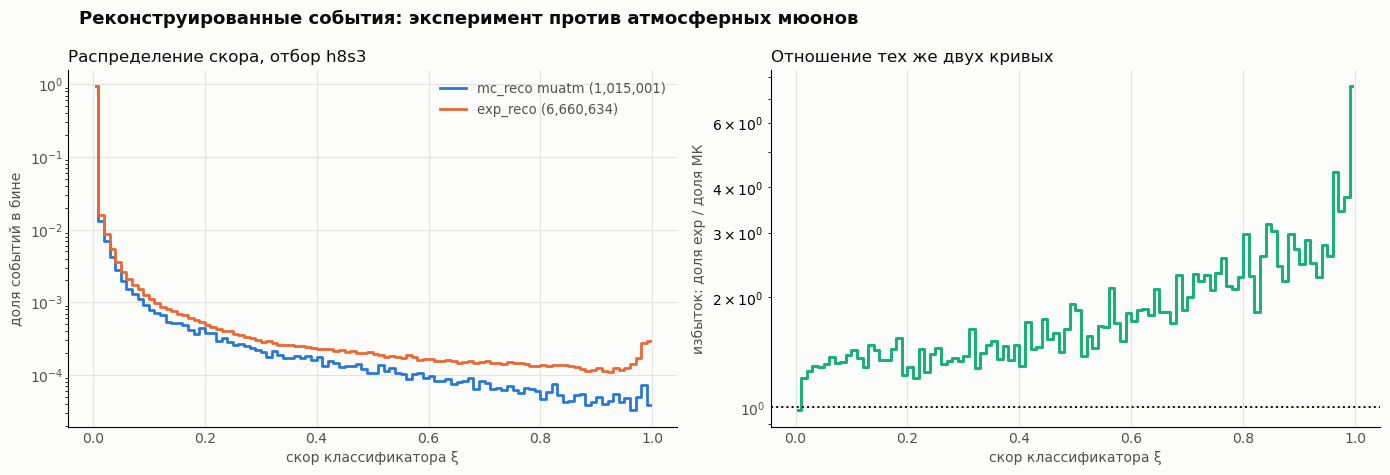

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
fig.patch.set_facecolor(SURFACE)
centres = 0.5 * (hist.bin_lo + hist.bin_hi)
for ax in axes:
    ax.set_facecolor(SURFACE); ax.grid(color="#e5e4e0", lw=0.8)
    ax.set_axisbelow(True); ax.tick_params(colors=MUTED, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)

ax = axes[0]
ax.step(centres, hist.mc_density, where="mid", color=BLUE, lw=2.0,
        label=f"mc_reco muatm ({hist.mc_count.sum():,})")
ax.step(centres, hist.exp_density, where="mid", color=ORANGE, lw=2.0,
        label=f"exp_reco ({hist.exp_count.sum():,})")
ax.set_yscale("log")
ax.set_xlabel("скор классификатора ξ", color=MUTED)
ax.set_ylabel("доля событий в бине", color=MUTED)
ax.set_title("Распределение скора, отбор h8s3", loc="left", fontsize=12, color=INK)
ax.legend(frameon=False, fontsize=9.5, labelcolor=MUTED)

ax = axes[1]
ratio = np.where(hist.mc_density > 0, hist.exp_density / hist.mc_density, np.nan)
ax.step(centres, ratio, where="mid", color=TEAL, lw=2.2)
ax.axhline(1.0, color=INK, ls=":", lw=1.4)
ax.set_yscale("log")
ax.set_xlabel("скор классификатора ξ", color=MUTED)
ax.set_ylabel("избыток: доля exp / доля МК", color=MUTED)
ax.set_title("Отношение тех же двух кривых", loc="left", fontsize=12, color=INK)
fig.suptitle("Реконструированные события: эксперимент против атмосферных мюонов",
             x=0.06, ha="left", fontsize=13, fontweight="bold", color=INK)
plt.tight_layout()
plt.savefig(HERE / "figures" / "04_reco_score.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()

Обе кривые падают на четыре порядка, и экспериментальная лежит выше модельной
тем сильнее, чем выше скор. Правая панель — то же самое как отношение.

## Шаг 4. Избыток по полосам

In [5]:
present.show(
    bands,
    {"score_lo": "полоса от", "score_hi": "до", "exp_events": "событий exp",
     "mc_events": "событий МК", "exp_share": "доля exp", "mc_share": "доля МК",
     "excess": "избыток"},
    rows="одна полоса скора",
    source=present.artefact_note(DATA / "04_bands.parquet"),
    note="Полосы непересекающиеся. Нижняя даёт 0.98 — там данные и симуляция "
         "совпадают, значит нормировка в порядке и рост дальше не артефакт.",
    decimals=5)
present.show(
    cumulative,
    {"threshold": "порог", "exp_events": "событий exp", "mc_events": "событий МК",
     "excess": "избыток"},
    rows="один порог (кумулятивно, для сопоставления с прежними числами)",
    source=present.artefact_note(DATA / "04_cumulative.parquet"),
    note="Для сравнения: exp_full против mc_merged даёт 2.87 при ξ>0.8.",
    decimals=4)

Строка — одна полоса скора.
Полосы непересекающиеся. Нижняя даёт 0.98 — там данные и симуляция совпадают, значит нормировка
в порядке и рост дальше не артефакт.
Источник: стадия 04_reco_excess, файл 04_bands.parquet, 7 строк


полоса от,до,событий exp,событий МК,доля exp,доля МК,избыток
0.000000,0.010000,6217778,965365,0.933510,0.951100,0.981510
0.010000,0.100000,284440,34364,0.042700,0.033860,1.261360
0.100000,0.300000,75925,8453,0.011400,0.008330,1.368750
0.300000,0.500000,31589,3239,0.004740,0.003190,1.486200
0.500000,0.700000,22118,1933,0.003320,0.001900,1.743670
0.700000,0.900000,18145,1167,0.002720,0.001150,2.369390
0.900000,1.000000,10639,480,0.001600,0.000470,3.377620


Строка — один порог (кумулятивно, для сопоставления с прежними числами).
Для сравнения: exp_full против mc_merged даёт 2.87 при ξ>0.8.
Источник: стадия 04_reco_excess, файл 04_cumulative.parquet, 4 строки


порог,событий exp,событий МК,избыток
0.500000,50902,3580,2.166700
0.800000,19232,993,2.951400
0.900000,10639,480,3.377600
0.990000,1941,39,7.584200


## Шаг 5. Насколько это зависит от исключений

In [6]:
wide = variants.pivot(index="variant", columns="threshold",
                      values="excess").reset_index()
counts = variants[variants.threshold == 0.5][["variant", "n_exp", "n_mc"]]
wide = wide.merge(counts, on="variant")
present.show(
    wide,
    {"variant": "отбор", 0.5: "избыток при ξ>0.5", 0.8: "при ξ>0.8",
     "n_exp": "событий exp", "n_mc": "событий МК"},
    rows="один вариант отбора",
    source=present.artefact_note(DATA / "04_variants.parquet"),
    note="Кластер 1 один поднимает избыток с 3.00 до 5.47 — это и есть причина "
         "его исключить. Остальные два исключения почти ничего не меняют. "
         "Последняя строка — с катами BARS на восходящие события; они срезают "
         "выборку в 70 раз, но избыток оставляют.",
    decimals=2)

Строка — один вариант отбора.
Кластер 1 один поднимает избыток с 3.00 до 5.47 — это и есть причина его исключить. Остальные
два исключения почти ничего не меняют. Последняя строка — с катами BARS на восходящие события;
они срезают выборку в 70 раз, но избыток оставляют.
Источник: стадия 04_reco_excess, файл 04_variants.parquet, 12 строк


отбор,избыток при ξ>0.5,при ξ>0.8,событий exp,событий МК
"all exclusions, up-going only (thetaRec < 90)",2.070000,2.710000,312497,47508
all three exclusions (the measurement),2.170000,2.950000,6660634,1015001
h8s3 only,2.970000,5.470000,6921465,1015034
"h8s3, without cluster 1",2.210000,3.000000,6678032,1015034
"h8s3, without cluster 1 and bad charge",2.170000,2.950000,6660634,1015002
plus the full BARS quality selection,1.760000,2.080000,5825,885


## Шаг 6. Рекомендованные каты BARS

Сначала я заключил, что применять их нельзя: вместе они оставляли 17.0%
симуляции и 0.013% данных, разница в 1 300 раз. **Это было неверно дважды**, и
обе ошибки стоит назвать, потому что каждая легко повторяется.

**Сравнивать надо с мюонами, а не со всей симуляцией.** Три из четырёх классов
`mc_reco` — нейтрино, и они действительно восходящие: `thetaRec < 80` оставляет
99.1% `nuatm_conv` против 2.1% `muatm`. Против всего файла кат выглядел
десятикратно асимметричным, против `muatm` его отношение 0.77.

**`evCenterZ` записан в абсолютных координатах, а хиты — в кластер-центрированных**,
и origin у файлов разный: центр экспериментального кластера на z = 361.7,
модельного — на 0.4. Отсюда медианы 474 и 40 и мнимая асимметрия ×10.8. После
приведения к центру кластера медианы 74.3 и 46.0, а кат оставляет 93.0% против
98.4%.

In [7]:
rates = pd.read_parquet(DATA / "03_cut_rates.parquet")
rates["ratio"] = rates.mc_muatm_alone / rates.exp_reco_alone
present.show(
    rates[["cut", "exp_reco_alone", "mc_muatm_alone", "ratio",
           "mc_nuatm_conv_alone", "caveat"]],
    {"cut": "кат", "exp_reco_alone": "оставляет в exp",
     "mc_muatm_alone": "оставляет в muatm", "ratio": "отношение",
     "mc_nuatm_conv_alone": "для сравнения: nuatm_conv",
     "caveat": "оговорка"},
    rows="один кат, применённый в одиночку",
    source=present.artefact_note(DATA / "03_cut_rates.parquet"),
    note="Все отношения лежат между 0.64 и 1.14 — список симметричен. Столбец "
         "nuatm_conv показывает, откуда бралась мнимая асимметрия: нейтрино "
         "восходящие, и включение их в знаменатель ломало сравнение.",
    decimals=4)
print(f"совокупно: exp {rates.exp_reco_cumulative.iloc[-1]:.5f}, "
      f"muatm {rates.mc_muatm_cumulative.iloc[-1]:.5f}, "
      f"отношение {rates.mc_muatm_cumulative.iloc[-1]/rates.exp_reco_cumulative.iloc[-1]:.2f}")

Строка — один кат, применённый в одиночку.
Все отношения лежат между 0.64 и 1.14 — список симметричен. Столбец nuatm_conv показывает,
откуда бралась мнимая асимметрия: нейтрино восходящие, и включение их в знаменатель ломало
сравнение.
Источник: стадия 03_cuts_and_quality, файл 03_cut_rates.parquet, 13 строк


кат,оставляет в exp,оставляет в muatm,отношение,для сравнения: nuatm_conv,оговорка
thetaRec < 80,0.026800,0.020600,0.767100,0.990700,
nHits >= 8,0.748100,0.752500,1.005900,0.749000,
nStrings >= 2,0.998500,0.995600,0.997100,0.992400,the current notebook uses >= 3
covMatrixStatus == 3,0.846700,0.906900,1.071000,0.864200,
scfMaxTheta < 1.7,0.012500,0.008100,0.644500,0.991400,
log10(pHit) > -9,0.987800,0.991800,1.004100,0.994800,flagged questionable in the source
evCenterZ_rel < 220,0.929600,0.984400,1.058900,0.995200,the raw field is in absolute coordinates whose origin differs between the files
zDist > 70,0.977400,0.974500,0.997100,0.994700,
pathLength > 50,0.987000,0.988500,1.001500,0.992800,
log10(funcValue / (nHits - 5)) < 1.1,0.491500,0.559800,1.139100,0.925500,flagged questionable; code applies 2.0


совокупно: exp 0.00105, muatm 0.00094, отношение 0.89


## Шаг 7. Где по углу сидит избыток

`thetaRec` — зенит, восстановленный **штатной реконструкцией BARS**, а не сетью.
Это важно: сеть его не видит, поэтому разбиение по нему не циклично, в отличие от
разбиения по собственной подгонке классификатора.

Прежняя работа на `exp_full` заключила, что избыток сидит **на горизонте**.
Проверяю это здесь — и не односторонним катом, а по полосам: односторонний кат
`thetaRec < X` убирает нисходящие, но горизонт оставляет, а горизонт есть
**полоса**, и чтобы её убрать, нужны две границы.

In [8]:
bandsθ = pd.read_parquet(DATA / "05_theta_bands.parquet")
present.show(
    bandsθ,
    {"theta_lo": "зенит от, °", "theta_hi": "до, °", "n_exp": "событий exp",
     "n_mc": "событий МК", "accepted_exp": "принято exp", "accepted_mc": "принято МК",
     "excess": "избыток", "excess_error": "ошибка"},
    rows="одна полоса восстановленного зенита",
    source=present.artefact_note(DATA / "05_theta_bands.parquet"),
    note="90° — горизонт, меньше — восходящие, больше — нисходящие. Ошибка "
         "пуассоновская, по числу принятых событий. Последние три полосы держатся "
         "на 35, 18 и 6 модельных событиях, поэтому читать их надо вместе.",
    decimals=3)

Строка — одна полоса восстановленного зенита.
90° — горизонт, меньше — восходящие, больше — нисходящие. Ошибка пуассоновская, по числу
принятых событий. Последние три полосы держатся на 35, 18 и 6 модельных событиях, поэтому читать
их надо вместе.
Источник: стадия 05_horizon_band, файл 05_theta_bands.parquet, 11 строк


"зенит от, °","до, °",событий exp,событий МК,принято exp,принято МК,избыток,ошибка
0,20.000000,6103,422,566,23,1.702000,0.362000
20,40.000000,9860,935,901,45,1.899000,0.290000
40,60.000000,25935,2888,1546,101,1.705000,0.175000
60,75.000000,67708,11281,2923,169,2.882000,0.228000
75,85.000000,110017,18308,3048,163,3.112000,0.250000
85,95.000000,231184,32575,3035,182,2.350000,0.179000
95,105.000000,539399,68040,2377,140,2.142000,0.186000
105,120.000000,1871165,239785,2386,111,2.755000,0.267000
120,140.000000,2525764,395826,1556,35,6.967000,1.191000
140,160.000000,1084723,209498,656,18,7.039000,1.682000


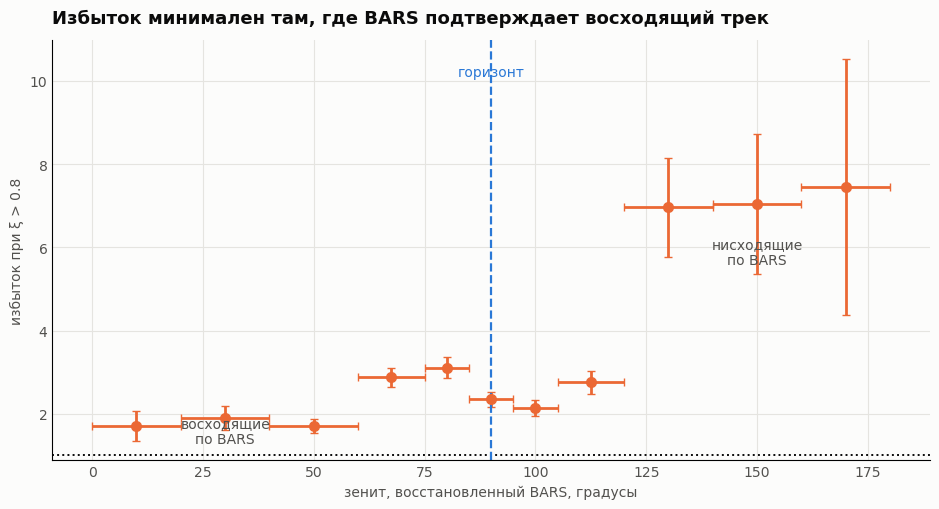

In [9]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
fig.patch.set_facecolor(SURFACE); ax.set_facecolor(SURFACE)
ax.grid(color="#e5e4e0", lw=0.8); ax.set_axisbelow(True)
ax.tick_params(colors=MUTED, length=0)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
centre = 0.5 * (bandsθ.theta_lo + bandsθ.theta_hi)
width = bandsθ.theta_hi - bandsθ.theta_lo
ax.errorbar(centre, bandsθ.excess, yerr=bandsθ.excess_error, xerr=width / 2,
            fmt="o", color=ORANGE, ecolor=ORANGE, lw=2.0, ms=7, capsize=3)
ax.axhline(1.0, color=INK, ls=":", lw=1.4)
ax.axvline(90, color=BLUE, ls="--", lw=1.6)
ax.annotate("горизонт", (90, ax.get_ylim()[1] * 0.92), color=BLUE, fontsize=10,
            ha="center")
ax.annotate("восходящие\nпо BARS", (30, 1.3), color=MUTED, fontsize=10, ha="center")
ax.annotate("нисходящие\nпо BARS", (150, 5.6), color=MUTED, fontsize=10, ha="center")
ax.set_xlabel("зенит, восстановленный BARS, градусы", color=MUTED)
ax.set_ylabel("избыток при ξ > 0.8", color=MUTED)
ax.set_title("Избыток минимален там, где BARS подтверждает восходящий трек",
             loc="left", fontsize=13, fontweight="bold", color=INK, pad=12)
plt.tight_layout()
plt.savefig(HERE / "figures" / "05_theta_bands.png", dpi=150, bbox_inches="tight",
            facecolor=SURFACE)
plt.show()

**Это противоположно тому, чего я ожидал, и противоречит прежнему выводу.**

Избыток **минимален** там, где BARS подтверждает восходящее направление:
1.70 ± 0.18 при зените 40–60°, 1.70 ± 0.36 при 0–20°. И **максимален** там, где
BARS уверенно говорит «нисходящее»: около **7** во всех трёх верхних полосах.
Разница больше четырёх стандартных отклонений.

Отсюда и парадокс кумулятивных катов: удаление горизонтной полосы **повышает**
избыток с 2.95 до 4.67, потому что оставшаяся выборка всё сильнее состоит из
явно нисходящих событий, где он и велик.

Содержательно это значит: **избыток сосредоточен там, где сеть и штатная
реконструкция расходятся**. События, которые BARS уверенно называет идущими
сверху, а классификатор принимает за нейтрино, встречаются в данных примерно
всемеро чаще, чем в симуляции. А в популяции, где обе процедуры согласны, что
трек восходящий, расхождение всего в 1.7 раза.

**Оговорка о статистике.** Три верхние полосы опираются на 35, 18 и 6 принятых
модельных событий. По отдельности каждая слаба, но все три согласуются между
собой, а нижние полосы, где статистики достаточно, дают устойчивые 1.7–1.9.

**Что это меняет для статьи.** В интересной для поиска нейтрино популяции —
там, где восходящее направление подтверждено независимой реконструкцией, —
расхождение данных и симуляции существенно меньше глобальных 2.95.

## Вывод

**Избыток воспроизводится на реконструированных событиях.** Профиль растёт от
**0.98** в нижней полосе до **3.38** в верхней; при ξ>0.8 он равен **2.95**
против **2.87**, измеренных на `exp_full` и `mc_merged`.

Это независимое подтверждение при **другом отборе событий**: reco-выборка
формируется успехом штатной реконструкции BARS, а не порогом на число хитов.
Согласие двух чисел говорит, что избыток — свойство данных, а не одного способа
отбирать события.

**Нормировка проверена:** в полосе ξ<0.01 избыток равен 0.98.

**Каты BARS его не убирают.** Полный набор из тринадцати условий снижает избыток
до **2.08**, только восходящие события дают **2.71**. Полный набор при этом
стоит трёх порядков статистики: остаётся 5 825 экспериментальных и 885 модельных
событий, так что 2.08 опирается на малую выборку.

**Чего это не говорит.** Природу избытка измерение не трогает — она разобрана в
`../response_vs_flux`, где показано, что дело в ошибке отклика детектора, а не в
потоке. Здесь проверено лишь, что явление не создано отбором.

**Оговорки.** `mc_reco` — другая продукция, чем `mc_merged`: классы называются
иначе, атмосферные нейтрино разделены на конвенциональные и прямые. Абсолютная
нормировка по-прежнему невозможна, сравниваются только формы.